# Notebook 05: Final training and RevisitOP evaluation

Train the best model on merged official SfM pairs (train + validation) for its fixed selected epoch count, then evaluate it once on the cached RevisitOP features. RevisitOP is not used for model selection.

In [1]:
from dataclasses import replace
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from cbir.cache import FeatureShardReader, load_revisitop_feature_cache
from cbir.config import FusionConfig, TrainingConfig, config_to_dict, load_project_config
from cbir.data.revisitop import RevisitOPDataset
from cbir.data.sfm import Sfm30kMetadata
from cbir.evaluation import descriptors_from_feature_tensors, evaluate_revisitop, ranked_ids_from_descriptors
from cbir.experiments import matching_experiment, read_selection, remove_experiment, save_experiment
from cbir.fusion import build_descriptor_head
from cbir.plotting import SeriesData, plot_series
from cbir.training import HeadTrainer
from cbir.utils import seed_everything
from cbir.workflow import full_sfm_cache_location, revisitop_feature_cache_location

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from the project root or notebooks directory.')
os.chdir(PROJECT_ROOT)

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'local.yaml'
cfg = load_project_config(CONFIG_PATH)
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '05_final_training_and_evaluation'
FIGURES_DIR = OUTPUT_DIR / 'figures'
RESULTS_PATH = OUTPUT_DIR / 'results.json'
FINAL_SELECTION_PATH = PROJECT_ROOT / 'outputs' / 'selections' / 'final_model_selection.json'
PREPARED_REVISIT_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'revisitop' / 'prepared'
DESCRIPTOR_BATCH_SIZE = 1024
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

selection = read_selection(FINAL_SELECTION_PATH)
fusion_raw = dict(selection['fusion_config'])
fusion_raw['layer_indices'] = tuple(fusion_raw['layer_indices'])
fusion_config = FusionConfig(**fusion_raw)
selected_training_config = TrainingConfig(**selection['training_config'])
TRAIN_BATCH_SIZE = selected_training_config.batch_size  # Lower only if VRAM requires it.
training_config = replace(selected_training_config, batch_size=TRAIN_BATCH_SIZE)
if TRAIN_BATCH_SIZE != selected_training_config.batch_size:
    print('Warning: final training uses a different batch size; this is recorded in results.json.')
FINAL_TRAIN_EPOCHS = int(selection['selected_epoch_count'])
if not 1 <= FINAL_TRAIN_EPOCHS <= training_config.epochs:
    raise ValueError('The selected epoch count is outside the training schedule.')

metadata = Sfm30kMetadata.from_official_files(
    cfg.sfm.metadata_path,
    cfg.sfm.names_clusters_path,
)
sfm_location = full_sfm_cache_location(cfg, metadata)
reader = FeatureShardReader(sfm_location.cache_dir, preload=True)
if reader.manifest.fingerprint != selection['cache_fingerprint']:
    raise ValueError('The selected model does not match the current SfM cache.')

print('Selected model:', selection['experiment_label'])
print('Final full-SfM epochs:', FINAL_TRAIN_EPOCHS)
print('Training batch size:', TRAIN_BATCH_SIZE)

Selected model: Dynamic layer weighting (8, 10, 12)
Final full-SfM epochs: 20
Training batch size: 512


## Final full-SfM training

The official SfM train and validation pairs are merged now. Training uses no validation split or early stopping.

In [2]:
full_sfm_pairs = (*metadata.train_pairs, *metadata.val_pairs)
final_run_spec = {
    'cache_fingerprint': reader.manifest.fingerprint,
    'fusion_config': config_to_dict(fusion_config),
    'training_config': config_to_dict(training_config),
    'selected_epoch_count': FINAL_TRAIN_EPOCHS,
    'training_pair_count': len(full_sfm_pairs),
}
final_record = matching_experiment(RESULTS_PATH, 'final_full_sfm', final_run_spec)
if final_record is None:
    remove_experiment(RESULTS_PATH, 'final_full_sfm')
    seed_everything(training_config.seed)
    head = build_descriptor_head(fusion_config)
    trainer = HeadTrainer(
        head=head,
        reader=reader,
        train_pairs=full_sfm_pairs,
        fusion_config=fusion_config,
        training_config=training_config,
        output_dir=OUTPUT_DIR / 'checkpoints' / 'final_full_sfm',
    )
    final_history = trainer.fit(
        max_epochs=FINAL_TRAIN_EPOCHS,
        enable_early_stopping=False,
        save_best_checkpoint=False,
    )
    final_checkpoint = trainer.save_final_checkpoint(final_history)
    final_summary = {
        'configuration': selection['experiment_label'],
        'training_pairs': len(full_sfm_pairs),
        'training_clusters': len({pair.cluster_id for pair in full_sfm_pairs}),
        'epochs_completed': len(final_history.epochs),
        'selected_epoch_count': FINAL_TRAIN_EPOCHS,
    }
    final_record = save_experiment(
        RESULTS_PATH,
        name='final_full_sfm',
        run_spec=final_run_spec,
        summary=final_summary,
        history=final_history.epochs,
        checkpoint=final_checkpoint,
    )
else:
    final_summary = final_record['summary']

FINAL_CHECKPOINT = OUTPUT_DIR / final_record['checkpoint']
display(pd.DataFrame([final_summary]))
print('Final checkpoint:', FINAL_CHECKPOINT)

,configuration,epochs_completed,selected_epoch_count,training_clusters,training_pairs
0,"Dynamic layer weighting (8, 10, 12)",20,20,713,30108


Final checkpoint: /home/armin/courses/ImageProcessing_FinalProject/outputs/05_final_training_and_evaluation/checkpoints/final_full_sfm/final.pt


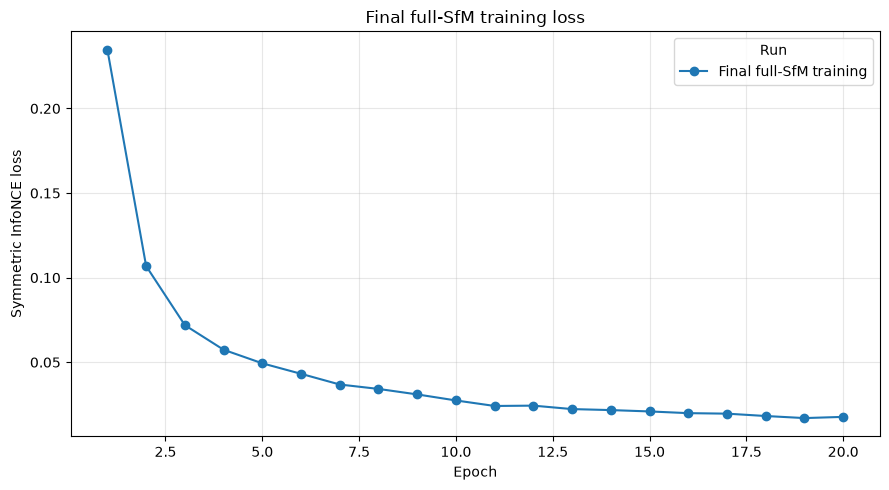

In [3]:
loss_history = final_record['history']
loss_figure, loss_axis = plot_series(
    {
        'Final full-SfM training': SeriesData(
            x=[int(epoch['epoch']) + 1 for epoch in loss_history],
            y=[epoch['loss'] for epoch in loss_history],
        )
    },
    title='Final full-SfM training loss',
    xlabel='Epoch',
    ylabel='Symmetric InfoNCE loss',
    legend_title='Run',
    fig_size=(9, 5),
    save_path=FIGURES_DIR / 'final_training_loss.png',
)
display(loss_figure)
plt.close(loss_figure)

## Held-out RevisitOP evaluation

This uses the cached frozen features from Notebook 04, full database images, official query crops, and the Medium and Hard protocols.

In [4]:
checkpoint = torch.load(FINAL_CHECKPOINT, map_location='cpu', weights_only=False)
head = build_descriptor_head(fusion_config)
head.load_state_dict(checkpoint['model_state_dict'])
head.eval()

datasets = {}
bundles = {}
revisit_fingerprints = {}
for dataset_name in ('roxford5k', 'rparis6k'):
    root = PREPARED_REVISIT_ROOT / dataset_name
    dataset = RevisitOPDataset.from_ground_truth_pickle(
        name=dataset_name,
        ground_truth_path=root / f'gnd_{dataset_name}.pkl',
        image_root=root / 'jpg',
    )
    location = revisitop_feature_cache_location(
        cfg, dataset, layer_indices=fusion_config.layer_indices
    )
    datasets[dataset_name] = dataset
    bundles[dataset_name] = load_revisitop_feature_cache(
        location.cache_dir, expected_fingerprint=location.fingerprint
    )
    revisit_fingerprints[dataset_name] = location.fingerprint

evaluation_spec = {
    'final_training_spec': final_run_spec,
    'revisit_cache_fingerprints': revisit_fingerprints,
    'descriptor_batch_size': DESCRIPTOR_BATCH_SIZE,
}
evaluation_record = matching_experiment(RESULTS_PATH, 'revisitop_evaluation', evaluation_spec)
if evaluation_record is None:
    evaluation_rows = []
    for dataset_name in ('roxford5k', 'rparis6k'):
        dataset = datasets[dataset_name]
        bundle = bundles[dataset_name]
        local_key = 'cls_guided_patch' if fusion_config.local_kind == 'cls_guided_patch' else 'mean_patch'
        database_descriptors = descriptors_from_feature_tensors(
            bundle['database']['cls'],
            head,
            local=bundle['database'][local_key],
            entropy=bundle['database']['pooling_entropy'],
            batch_size=DESCRIPTOR_BATCH_SIZE,
            device=training_config.device,
        )
        query_descriptors = descriptors_from_feature_tensors(
            bundle['queries']['cls'],
            head,
            local=bundle['queries'][local_key],
            entropy=bundle['queries']['pooling_entropy'],
            batch_size=DESCRIPTOR_BATCH_SIZE,
            device=training_config.device,
        )
        rankings = ranked_ids_from_descriptors(
            query_descriptors,
            database_descriptors,
            dataset.database_ids,
            query_block_size=cfg.evaluation.query_block_size,
        )
        report = evaluate_revisitop(
            rankings,
            bundle['queries']['image_ids'],
            dataset.ground_truth,
        )
        evaluation_rows.append({
            'dataset': dataset_name,
            'medium_map': report.medium.map,
            'medium_mp10': report.medium.mean_precision_at_10,
            'hard_map': report.hard.map,
            'hard_mp10': report.hard.mean_precision_at_10,
        })
    evaluation_summary = {'results': evaluation_rows}
    evaluation_record = save_experiment(
        RESULTS_PATH,
        name='revisitop_evaluation',
        run_spec=evaluation_spec,
        summary=evaluation_summary,
        history=[],
        checkpoint=None,
    )
else:
    evaluation_summary = evaluation_record['summary']

evaluation_table = pd.DataFrame(evaluation_summary['results'])
display(evaluation_table)

,dataset,medium_map,medium_mp10,hard_map,hard_mp10
0,roxford5k,0.554252,0.727143,0.302227,0.395952
1,rparis6k,0.788676,0.962857,0.613753,0.851429


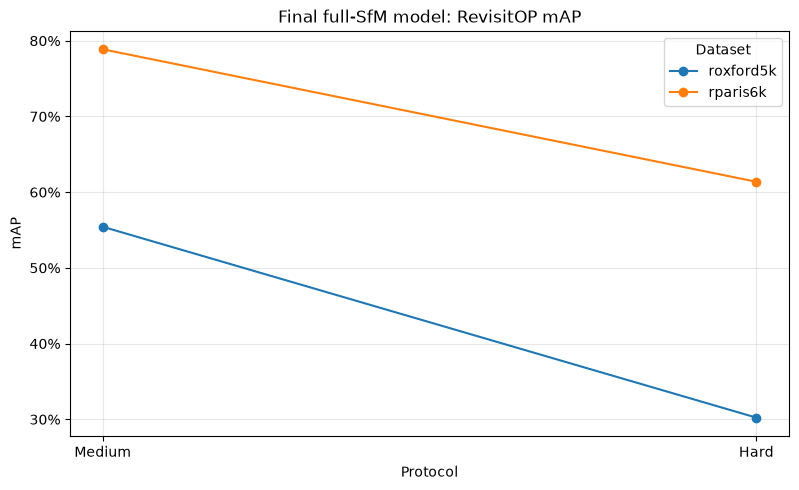

In [5]:
map_series = {
    row['dataset']: SeriesData(x=[0, 1], y=[row['medium_map'], row['hard_map']])
    for row in evaluation_summary['results']
}
map_figure, map_axis = plot_series(
    map_series,
    title='Final full-SfM model: RevisitOP mAP',
    xlabel='Protocol',
    ylabel='mAP',
    legend_title='Dataset',
    fig_size=(8, 5),
    save_path=FIGURES_DIR / 'revisitop_map.png',
)
map_axis.set_xticks([0, 1], ['Medium', 'Hard'])
map_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
display(map_figure)
plt.close(map_figure)